# Open Gym Analytics — Análisis exploratorio de datos

## Objetivo
Analizar patrones de uso de espacios deportivos comunitarios para identificar actividades, horarios y centros con mayor utilización.

## Importante sobre las métricas
El dashboard original de Power BI utiliza en varias visualizaciones el **recuento de registros** de `Total Asistentes`. En este notebook se distinguen dos métricas:

- **Registros:** cantidad de filas del dataset.
- **Asistentes:** suma de la columna `total_asistentes`.

Esta distinción evita confundir frecuencia de registros con cantidad de personas registradas.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
df = pd.read_csv("../data/processed/open-gym-clean.csv")
df.head()


,fecha_hora_apertura,fecha_hora_cierre,total_mujeres,total_hombres,total_extranjeros,total_residentes,total_asistentes,nombre_instalacion,ubicacion,direccion,provincia,codigo_postal,tipo_entrada,centro_comunitario,gimnasio_abierto,grupo,fecha,hora,dia_semana,duracion_horas
0,2008-09-15 19:00:00+00:00,2008-09-15 21:30:00+00:00,NaN,NaN,NaN,NaN,0,Bond Park Community Center,Magnolia Gymnasium,150 Metro Park,NC,27513.0,Open Gym - Youth/Teen BB,BPCC,Basketball,Youth/Teen,2008-09-15,19,Monday,2.5
1,2008-09-17 21:00:00+00:00,2008-09-18 00:00:00+00:00,NaN,NaN,NaN,NaN,0,Herbert C. Young Community Center,Room B,101 Wilkinson AVE,NC,27513.0,Open Table Tennis,HYCC,Table Tennis,Sin dato,2008-09-17,21,Wednesday,3.0
2,2008-09-29 16:00:00+00:00,2008-09-29 18:00:00+00:00,NaN,NaN,NaN,NaN,0,Herbert C. Young Community Center,Coach Kay Yow Court,101 Wilkinson AVE,NC,27513.0,Open Gym,HYCC,Open Gym,Sin dato,2008-09-29,16,Monday,2.0
3,2008-10-01 19:00:00+00:00,2008-10-01 21:30:00+00:00,NaN,NaN,NaN,NaN,0,Bond Park Community Center,Magnolia Gymnasium,150 Metro Park,NC,27513.0,Open Gym - Youth/Teen BB,BPCC,Basketball,Youth/Teen,2008-10-01,19,Wednesday,2.5
4,2008-10-08 16:00:00+00:00,2008-10-08 18:00:00+00:00,NaN,NaN,NaN,NaN,0,Herbert C. Young Community Center,Coach Kay Yow Court,101 Wilkinson AVE,NC,27513.0,Open Gym,HYCC,Open Gym,Sin dato,2008-10-08,16,Wednesday,2.0


## 1. Exploración inicial

In [2]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
df.dtypes


Filas: 28038
Columnas: 20


fecha_hora_apertura        str
fecha_hora_cierre          str
total_mujeres          float64
total_hombres          float64
total_extranjeros      float64
total_residentes       float64
total_asistentes         int64
nombre_instalacion         str
ubicacion                  str
direccion                  str
provincia                  str
codigo_postal          float64
tipo_entrada               str
centro_comunitario         str
gimnasio_abierto           str
grupo                      str
fecha                      str
hora                     int64
dia_semana                 str
duracion_horas         float64
dtype: object

In [3]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("valores_nulos")
missing["porcentaje"] = (missing["valores_nulos"] / len(df) * 100).round(2)
missing


,valores_nulos,porcentaje
total_extranjeros,18104,64.57
total_mujeres,17657,62.98
total_hombres,14717,52.49
total_residentes,13954,49.77
codigo_postal,4,0.01
provincia,4,0.01
nombre_instalacion,4,0.01
direccion,4,0.01
fecha_hora_apertura,0,0.00
fecha_hora_cierre,0,0.00


## 2. Variables derivadas
Se utilizaron `fecha`, `hora`, `dia_semana` y `duracion_horas` para facilitar el análisis temporal.


In [4]:
df[["fecha_hora_apertura","fecha_hora_cierre","fecha","hora","dia_semana","duracion_horas"]].head()


,fecha_hora_apertura,fecha_hora_cierre,fecha,hora,dia_semana,duracion_horas
0,2008-09-15 19:00:00+00:00,2008-09-15 21:30:00+00:00,2008-09-15,19,Monday,2.5
1,2008-09-17 21:00:00+00:00,2008-09-18 00:00:00+00:00,2008-09-17,21,Wednesday,3.0
2,2008-09-29 16:00:00+00:00,2008-09-29 18:00:00+00:00,2008-09-29,16,Monday,2.0
3,2008-10-01 19:00:00+00:00,2008-10-01 21:30:00+00:00,2008-10-01,19,Wednesday,2.5
4,2008-10-08 16:00:00+00:00,2008-10-08 18:00:00+00:00,2008-10-08,16,Wednesday,2.0


In [5]:
# Métricas por actividad
activity_records = df.groupby("gimnasio_abierto").size()
activity_attendance = df.groupby("gimnasio_abierto")["total_asistentes"].sum()

# Métricas por hora
hour_records = df.groupby("hora").size()
hour_attendance = df.groupby("hora")["total_asistentes"].sum()

# Métricas por centro comunitario
center_attendance = df.groupby("centro_comunitario")["total_asistentes"].sum()



## 3. KPIs principales

In [6]:
kpis = pd.Series({
    "Total de asistentes registrados": int(df["total_asistentes"].sum()),
    "Número de registros": int(len(df)),
    "Promedio de asistentes por registro": round(df["total_asistentes"].mean(), 2),
    "Actividad con más registros": activity_records.index[0],
    "Actividad con más asistentes": activity_attendance.index[0],
    "Hora con más registros": int(hour_records.index[0]),
    "Hora con más asistentes": int(hour_attendance.index[0]),
    "Centro con más asistentes": center_attendance.index[0],
})
kpis


Total de asistentes registrados           171413
Número de registros                        28038
Promedio de asistentes por registro         6.11
Actividad con más registros            Badminton
Actividad con más asistentes           Badminton
Hora con más registros                         0
Hora con más asistentes                        0
Centro con más asistentes                   BPCC
dtype: object

## 4. Actividades: registros vs. asistentes
Esta comparación es importante porque el dashboard de Power BI presenta el recuento de registros, mientras que aquí también se analiza la suma de asistentes.


In [7]:
activity = pd.DataFrame({
    "registros": activity_records,
    "asistentes": activity_attendance
}).sort_values("asistentes", ascending=False)

activity


,registros,asistentes
gimnasio_abierto,,
Pickleball,2929,43565
Badminton,1956,43479
Basketball,8971,28513
Volleyball,2071,23847
Open Studio,2491,18099
Table Tennis,1318,5479
Open Gym,7643,4082
Preschool,379,3884
Homeschool,143,465


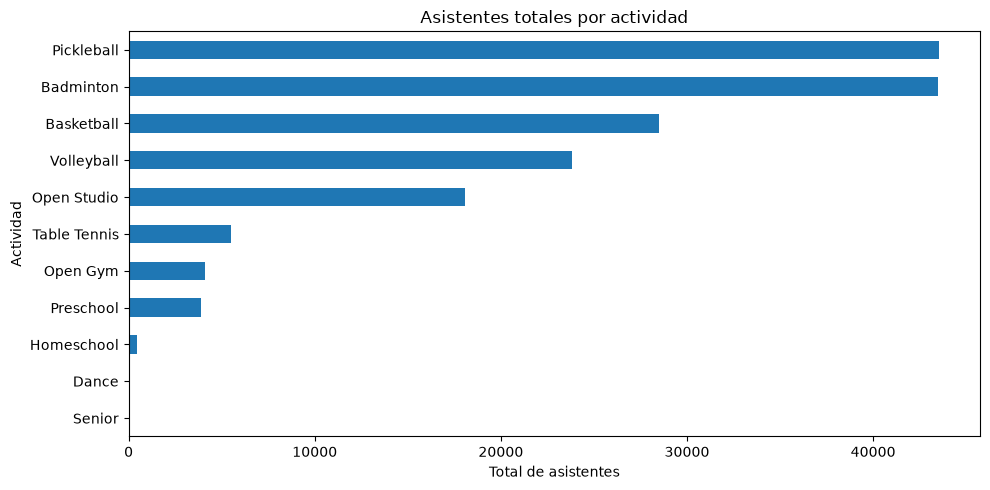

In [8]:
fig, ax = plt.subplots(figsize=(10,5))
activity["asistentes"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Asistentes totales por actividad")
ax.set_xlabel("Total de asistentes")
ax.set_ylabel("Actividad")
plt.tight_layout()
plt.show()


## 5. Horarios
Se analizan tanto el número de registros como la suma de asistentes por hora.


In [9]:
hour = pd.DataFrame({
    "registros": hour_records,
    "asistentes": hour_attendance
}).sort_index()

hour


,registros,asistentes
hora,,
0,482,1174
1,144,185
2,2,0
10,27,0
11,43,0
12,86,1948
13,2735,35822
14,1721,23965
15,417,2664


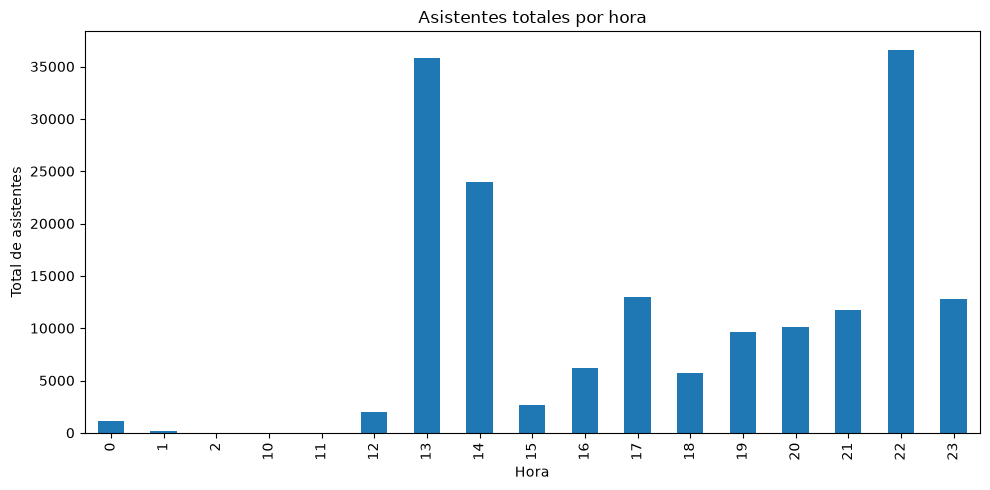

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
hour["asistentes"].plot(kind="bar", ax=ax)
ax.set_title("Asistentes totales por hora")
ax.set_xlabel("Hora")
ax.set_ylabel("Total de asistentes")
plt.tight_layout()
plt.show()


## 6. Centros comunitarios

In [11]:
center = pd.DataFrame({
    "registros": df.groupby("centro_comunitario")["total_asistentes"].count(),
    "asistentes": center_attendance
}).sort_values("asistentes", ascending=False)

center


,registros,asistentes
centro_comunitario,,
BPCC,11498,108931
HYCC,8205,23733
MCCC,5840,20650
CAC,2491,18099
Sin dato,4,0


## 7. Distribución registrada por género

In [13]:
gender = pd.Series({
    "Hombres": df["total_hombres"].sum(),
    "Mujeres": df["total_mujeres"].sum()
})
gender


Hombres    115635.0
Mujeres     55768.0
dtype: float64

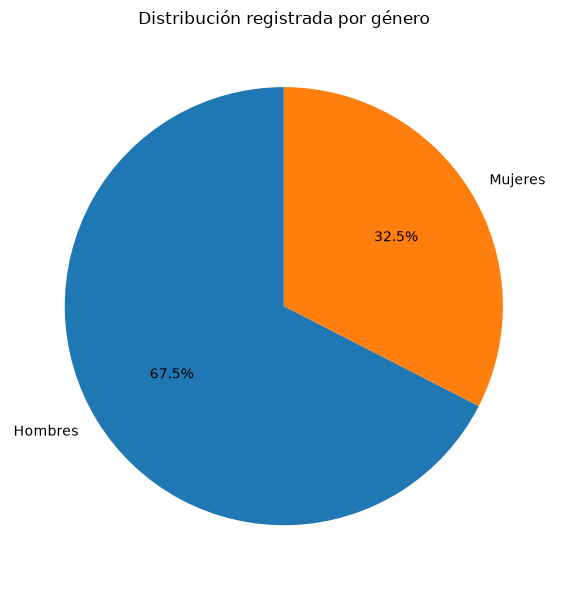

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(gender.values, labels=gender.index, autopct="%1.1f%%", startangle=90)
ax.set_title("Distribución registrada por género")
plt.tight_layout()
plt.show()


## 8. Hallazgos
- El dataset contiene **28.038 registros** y acumula **171.413 asistentes** en la columna `total_asistentes`.
- **Basketball** es la actividad con más registros (8.971), seguida por **Open Gym** (7.643).
- Si la métrica es la suma de `total_asistentes`, **Pickleball** y **Badminton** acumulan los mayores valores.
- Por suma de asistentes, las horas con mayor volumen son **22:00, 13:00 y 14:00**.
- **BPCC** es el centro con mayor suma de asistentes.
- El dashboard de Power BI debe interpretarse teniendo presente que varias visualizaciones muestran **recuento de registros**, no suma de asistentes.


## 9. Conclusión
El proyecto permite analizar la utilización de espacios deportivos desde dos perspectivas complementarias: frecuencia de registros y volumen acumulado de asistentes. La separación de estas métricas mejora la precisión de las conclusiones y evita interpretar un recuento de filas como si fuera una cantidad de personas.
